In [ ]:
# !pip install pandas seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [15]:
from collections import Counter
import re
from pathlib import Path

input_path = Path("input.txt")
raw_text = input_path.read_text(encoding="utf-8")
raw_text = re.sub(r"===\s*[^=\n]+\s*===", " ", raw_text)
raw_text = re.sub(r"^\s*import\s+[\"'][^\"'\n]+[\"']\s*;?\s*$", " ", raw_text, flags=re.IGNORECASE | re.MULTILINE)

cleaned_tokens = re.findall(r"[a-zA-Z]+", raw_text.lower())
bag_of_words = Counter(cleaned_tokens)

In [16]:
import pandas as pd
counts_df = pd.DataFrame(bag_of_words.items(), columns=["token", "count"])

counts_df["token"] = counts_df["token"].str.lower()

counts_df = counts_df.sort_values("count", ascending=False).reset_index(drop=True)

counts_df.head(20)

,token,count
0,final,2648
1,context,2602
2,return,1321
3,const,1278
4,this,1267
5,widget,1006
6,child,989
7,data,935
8,required,920
9,error,896


/var/folders/y7/3khx9vbx74z9_0bd7nswgf080000gn/T/ipykernel_6727/1061399290.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="count", y="token", palette="viridis")


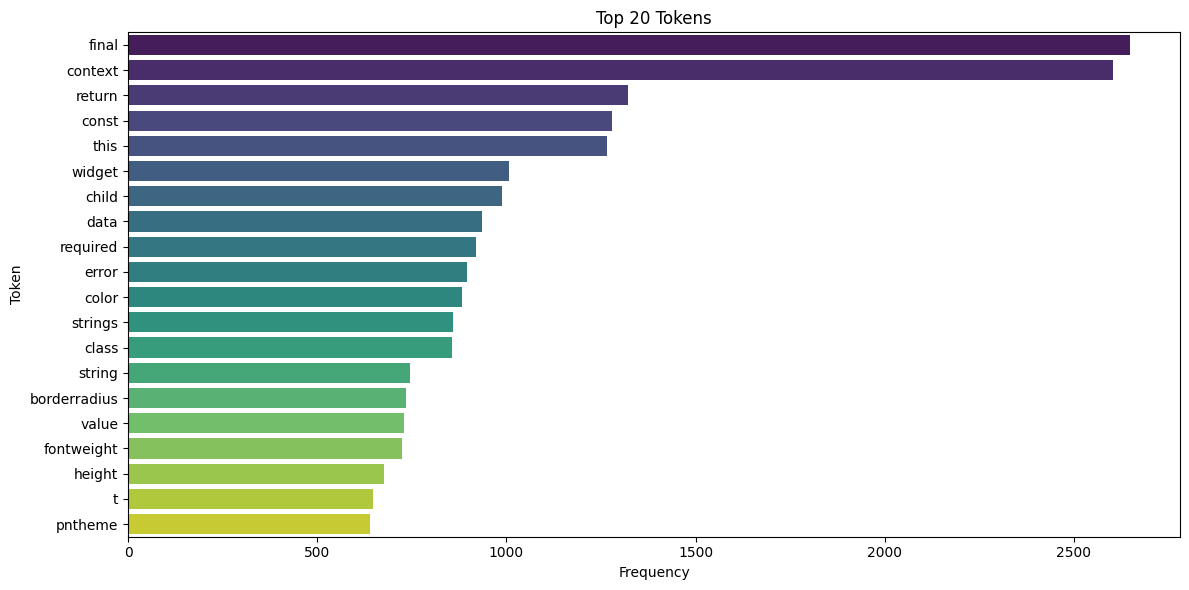

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 20
plot_df = counts_df.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="count", y="token", palette="viridis")
plt.title(f"Top {top_n} Tokens")
plt.xlabel("Frequency")
plt.ylabel("Token")
plt.tight_layout()
plt.show()